# OP26 — Phase 4: Tariff Pricing Agent
Turns the Phase-3 demand forecast into a bounded **dynamic per-kWh tariff** and quantifies the brief's three metrics against a flat baseline: **Revenue Gain %**, **Charger Utilization before/after**, and **Off-Peak Uplift**. Logic in `pricing.py`.

**Method:** constant-elasticity demand q(p)=q0·(p/p0)^ε with ε estimated (FWL, zone+hour+dow FE) on the price-varying zones — *associational, not causal*. Policy = surge ramp for forecast util ≥ 0.80, discount ramp for < 0.30, neutral between. Every 'after' number is **simulated under the estimated elasticity** on the held-out test window.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path.cwd().parent))
import pandas as pd
from IPython.display import Image, display
import config as C, pricing as PR
panel = pd.read_csv(C.OUTPUT_DIR/'urbanev_panel_hourly.csv.gz')
test  = pd.read_csv(C.OUTPUT_DIR/'demand_predictions.csv')
p0_map = panel.groupby('zone')['price_mean'].mean().to_dict()

## 1. Elasticity (associational)
Demand is **inelastic** (|ε|<1): higher price → proportionally smaller demand drop.

In [2]:
est, eps_e, eps_u = PR.estimate_elasticity(panel)
display(est)
print(f'using ε_energy = {eps_e:+.3f}, ε_util = {eps_u:+.3f}')

,target,scope,elasticity,se,ci_low,ci_high,n,price_varying_zones
0,energy_kwh,overall,-0.3214,0.0119,-0.3447,-0.2981,76754,108
1,energy_kwh,peak_hours,-0.7239,0.0266,-0.7761,-0.6717,25612,108
2,energy_kwh,offpeak_hours,-0.0092,0.0501,-0.1074,0.0891,25532,108
3,utilization,overall,-0.2479,0.0075,-0.2625,-0.2333,77520,108
4,utilization,peak_hours,-0.4238,0.0150,-0.4531,-0.3944,25852,108
5,utilization,offpeak_hours,-0.1356,0.0304,-0.1951,-0.0760,25831,108


using ε_energy = -0.321, ε_util = -0.248


## 2. Policy + trade-off sweep
Because demand is inelastic and off-peak holds far more energy than the rare congested slots, revenue cannot be meaningfully grown — so we map the revenue↔uplift↔congestion frontier and pick a **revenue-neutral load-shifting** operating point.

recommended bounds: discount 0.90x / surge 1.60x


,forecast_utilization,multiplier,region,tariff_inr_per_kwh,tariff_cny_example
0,0.0,0.900,discount,13.5,0.863
4,0.2,0.967,discount,14.5,0.927
8,0.4,1.000,neutral,15.0,0.959
12,0.6,1.000,neutral,15.0,0.959
16,0.8,1.000,surge,15.0,0.959
20,1.0,1.600,surge,24.0,1.534


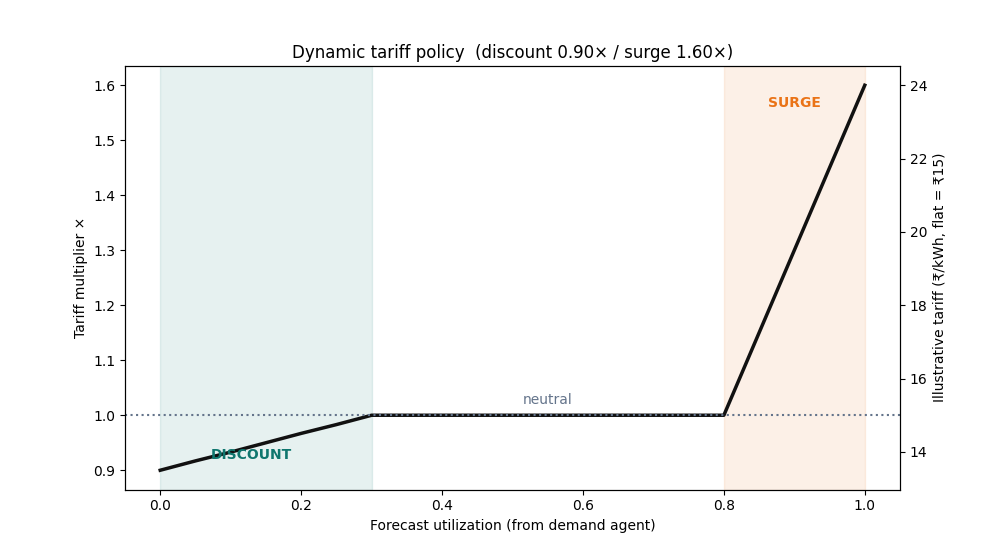

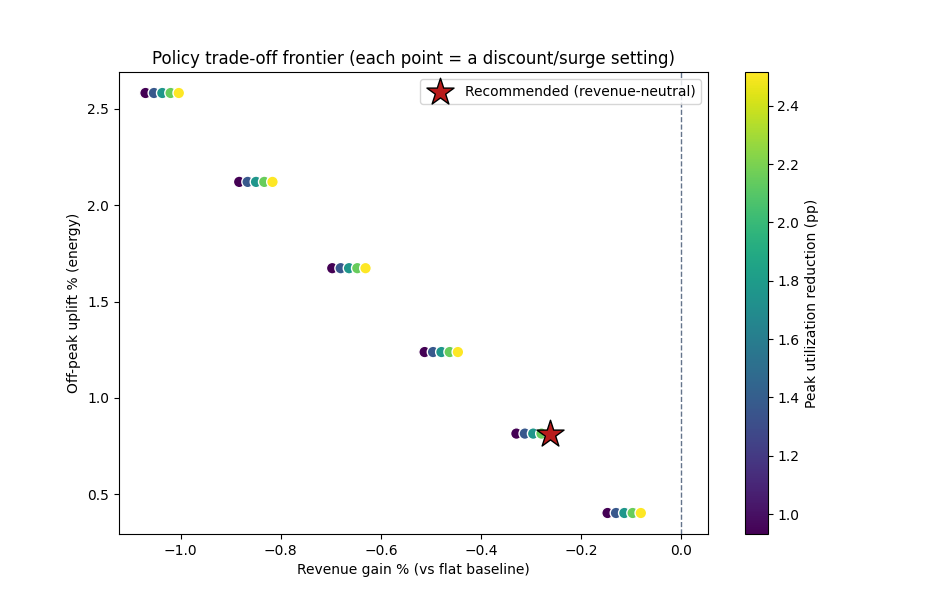

In [3]:
sw, m_min, m_max = PR.sweep(test, eps_e, eps_u, p0_map)
pol = PR.policy_table(eps_e, m_min, m_max, panel.price_mean.mean())
print(f'recommended bounds: discount {m_min:.2f}x / surge {m_max:.2f}x')
display(pol.iloc[::4])               # policy table (every 0.20 util)
display(Image(C.FIG_DIR/'fig12_pricing_policy.png'))
display(Image(C.FIG_DIR/'fig13_policy_frontier.png'))

## 3. Outcomes for the recommended policy (simulated, test window)

Revenue gain %      : -0.26
Utilization        : 0.2922 -> 0.2928
Off-peak uplift %   : +0.82
Peak util          : 0.873 -> 0.847 (+2.59 pp)


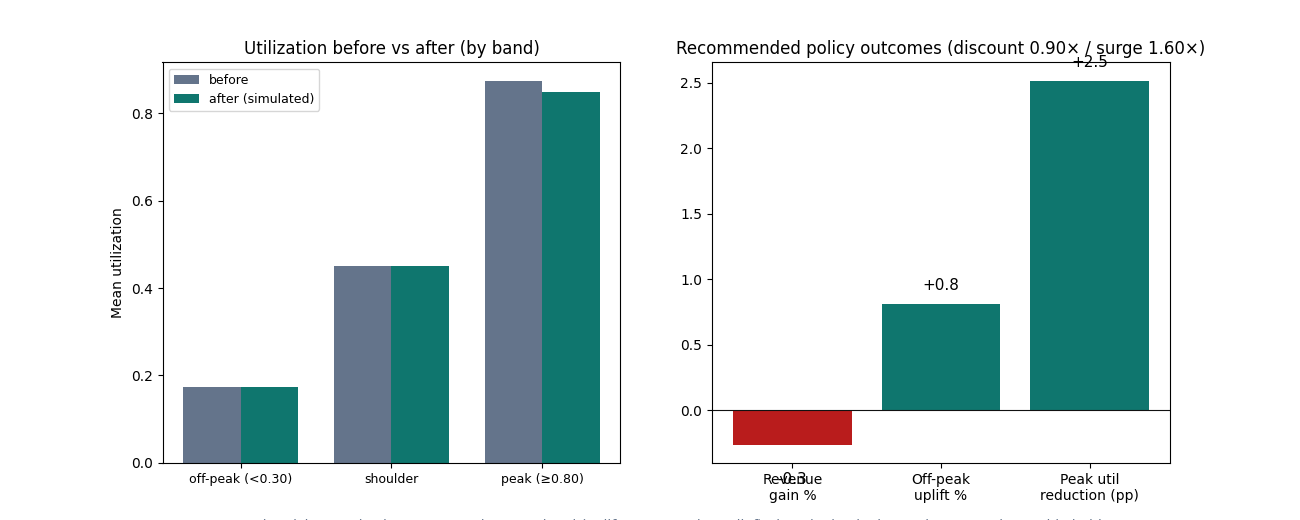

In [4]:
rec, sim = PR.simulate(test, eps_e, eps_u, m_min, m_max, p0_map)
print('Revenue gain %%      : %+.2f' % rec['rev_gain_pct'])
print('Utilization        : %.4f -> %.4f' % (rec['util_before'], rec['util_after']))
print('Off-peak uplift %%   : %+.2f' % rec['offpeak_uplift_pct'])
print('Peak util          : %.3f -> %.3f (%+.2f pp)' % (rec['peak_util_before'], rec['peak_util_after'], rec['peak_reduction_pp']))
display(Image(C.FIG_DIR/'fig14_outcomes.png'))

**Honest conclusion:** under inelastic demand, dynamic pricing here is a **load-balancing tool, not a revenue tool** — best-case revenue is ~neutral, but surging the rare congested slots buys ~2.5pp of peak relief at almost no revenue cost, plus modest off-peak uplift. See `outputs/pricing_findings.md`.

---
**Phase 4 complete.** Recommended bounds + `tariff_simulation.csv` feed **Phase 5 — the Monitoring & Learning Agent**, which rolls the policy out episode-by-episode and adapts online.